# Tier 4: 高度統計・ML 手法 — 解説 + フル再計算

本ノートは Tier 4 の 7 手法を自己完結で解説・再計算する（Run All で全計算が走る）：

`fisher_wknn` / `mahalanobis_wknn` / `pls_corridor` / `ordinal_corridor` /
`wcl_residual` / `joint_fp` / `gp_augmented_wknn`

実装は複製せず、`icsr8`（`icsr8.harness_tier4` の公開関数
`run_protocol_a_tier4` / `run_lolo_tier4`）を import して評価する。乱数種と
bootstrap 反復数は `icsr8.constants.RANDOM_SEED` / `B=1000` で本番
`results/tier4/` と同一条件に固定し、最後に凍結 CSV と数値照合する。

**書き込み方針**: このノートは `results/` や `doc/` に一切書き込まない。全指標は
メモリ上の DataFrame として計算し、図はインライン表示する。

## 1. 概要 — Tier 4 の位置づけと主要比較

**Tier 1〜3** は WCL / fingerprint パイプラインの部品差し替え（重み関数・候補 AP・
Student-t 集約など）の ablation 群だった。**Tier 4** はそれを超えて、
*高度な統計・機械学習手法*を持ち込む層である：

| 手法 | 系統 | 一言 |
|---|---|---|
| `fisher_wknn` (#13) | 特徴選択 + WKNN | Fisher score で情報量の高い (AP, band) 鍵に絞る |
| `mahalanobis_wknn` (#14) | 距離計量学習 | 共分散 shrinkage で相関を考慮した Mahalanobis 距離 |
| `pls_corridor` (#15) | 次元圧縮回帰 | PLS で廊下弧長 s を直接回帰 |
| `ordinal_corridor` (#17) | 順序回帰 | 累積確率 P(s>c_k) を積分して弧長を再構成 |
| `wcl_residual` (#18) | 残差学習 | WCL 弧長推定の残差を Ridge で補正 |
| `joint_fp` (#19) | 複合距離 | RSSI + 検出率の複合 fingerprint 距離 |
| `gp_augmented_wknn` (#20) | 半教師 data augmentation | GP radio map で仮想 fingerprint を廊下上に合成 |

### 主要比較基準は `gp_corridor`（事前指定）

Tier 4 の評価では、**主要比較基準を `gp_corridor` に事前指定**している。理由は
`gp_corridor` が既存の全 Tier で最良（LOLO Ave 0.72 m）だからで、「新しい高度手法が
その最良基準を上回れるか」が Tier 4 の中心問いである。そのため評価ハーネス
`icsr8.harness_tier4` は、各手法について `delta_vs_wcl`（素朴ベースライン差）と
`delta_vs_gp_corridor`（最良基準差）の **2 本の paired bootstrap CI** を出力する。
9 手法（Tier4 の 7 + 参照 `wcl`, `gp_corridor`）を同一 fold 集合で回すのは、この
delta 列を完全ペアリング契約のもとで算出するために必須である。

### 手法 #16（segment-first, coordinate-second）は `gp_corridor` に実装済み

Tier 4 の一覧に #16 が単独手法として現れないのは、**#16 が `gp_corridor` の内部段
として既に実装されているため**である。`gp_corridor` は
「(1) WKNN 特徴行列からロジスティック分類器で L 字廊下の *segment*（C / C2 / C3）を
先に当て、(2) その segment 内でのみ GP 事後平均から弧長 s を回帰する」という
2 段構成を取る（`src/icsr8/methods/gp_corridor.py` の segment 分類器・
`SEGMENT_RANGES`）。この segment-first → coordinate-second が #16 の狙いそのものであり、
本ノートでは `gp_corridor` を参照手法として回すことで #16 の寄与も同時に評価される。

## 2. データ読み込み

`notebooks/` から実行してもリポジトリルートから実行しても動くようパスを解決する
（`os.chdir` は使わない）。`data/dataset`（AP 座標・地点座標）と
`data/rawdata`（forward / backward 生スキャン）を読み込む。

In [1]:
%matplotlib inline
import platform
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from icsr8.constants import RANDOM_SEED, CORRIDOR_SEGMENTS
from icsr8.corridor import arclength_to_xy, xy_to_arclength
from icsr8.harness_tier4 import (
    REFERENCE_METHODS,
    TIER4_METHODS,
    run_lolo_tier4,
    run_protocol_a_tier4,
)
from icsr8.io import load_ap_coords, load_location_coords, load_raw_scans
from icsr8.methods._tier4 import dense_matrix, location_feature_stats
from icsr8.protocols import iter_protocol_a

# notebooks/ からでも repo ルートからでも解決（os.chdir 禁止）。
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = REPO / "data" / "dataset"
RAWDATA_ROOT = REPO / "data" / "rawdata"
RESULTS_DIR = REPO / "results" / "tier4"

SEED = RANDOM_SEED
B = 1000
ALL_METHODS = TIER4_METHODS + REFERENCE_METHODS
timings: dict[str, float] = {}

print("Tier4 手法:", TIER4_METHODS)
print("参照手法  :", REFERENCE_METHODS)
print(f"seed={SEED}  B={B}  評価対象={len(ALL_METHODS)} 手法")


Tier4 手法: ['fisher_wknn', 'mahalanobis_wknn', 'pls_corridor', 'ordinal_corridor', 'wcl_residual', 'joint_fp', 'gp_augmented_wknn']
参照手法  : ['wcl', 'gp_corridor']
seed=0  B=1000  評価対象=9 手法


In [2]:
t0 = time.perf_counter()
ap13 = load_ap_coords(DATASET_DIR / "AP_coordinate_C3F.csv")
truth = load_location_coords(DATASET_DIR / "location_coordinate_C.csv")[
    ["location_p", "x", "y"]
]
scans_f = load_raw_scans("forward", RAWDATA_ROOT)
scans_b = load_raw_scans("backward", RAWDATA_ROOT)
timings["data_load"] = time.perf_counter() - t0

print(f"AP (3F, 13台): {len(ap13)}")
print(f"地点数        : {len(truth)}")
print(f"forward scans : {len(scans_f)} 行")
print(f"backward scans: {len(scans_b)} 行")
truth.head()


AP (3F, 13台): 13
地点数        : 59
forward scans : 16659 行
backward scans: 17432 行


,location_p,x,y
0,1,32,0
1,2,30,0
2,3,28,0
3,4,26,0
4,5,24,0


## 3. 各手法のデモ

各手法が baseline から何を変えているかを、Protocol A の
**forward→backward fold**（train=forward, test=backward）を共通の観察対象として
1 つずつ確認する。推定器の内部は再実装せず、`icsr8` の公開クラスと共有ヘルパ
（`location_feature_stats` 等）を呼んで結果を観察する。各 fit が返す
`diagnostics_`（inner CV で選ばれたハイパーパラメータ）も表示する。

In [3]:
demo_fold = next(iter(iter_protocol_a(scans_f, scans_b)))
demo_train = demo_fold.train_scans
demo_test = demo_fold.test_scans
demo_stats = location_feature_stats(demo_train)
print("demo fold:", demo_fold.name)
print("train 地点数:", demo_train["location_p"].nunique(),
      " test 地点数:", demo_test["location_p"].nunique())
print("(ap_name, band) 鍵の総数:", demo_stats.mu.shape[1])


demo fold: forward_to_backward
train 地点数: 59  test 地点数: 59
(ap_name, band) 鍵の総数: 102


### 3.1 fisher_wknn — Fisher score による鍵選択

各 (ap_name, band) 鍵の Fisher score $F = \mathrm{Var}_l(\mu_l) / \overline{\sigma_l^2}$
（地点間の平均分離度 ÷ 地点内分散）を計算し、上位 $M$ 鍵に絞って WKNN する。
$M/k/$重み付けは inner CV で選ぶ。上位スコア鍵ほど「地点によって RSSI が大きく動き、
かつ測定が安定」な情報量の高い鍵である。

diagnostics_: {'selected_M': 32, 'selected_k': 5, 'selected_weighting': 'inv_sq', 'n_selected_keys': 32, 'cv_best_score': 1.6687558587101587}
評価対象鍵 80 本のうち上位 32 本を採用


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1976261927.py:20: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1976261927.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1976261927.py:20: UserWarning: Glyph 37749 (\N{CJK UNIFIED IDEOGRAPH-9375}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1976261927.py:20: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kinoko/Development/github/icsR8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

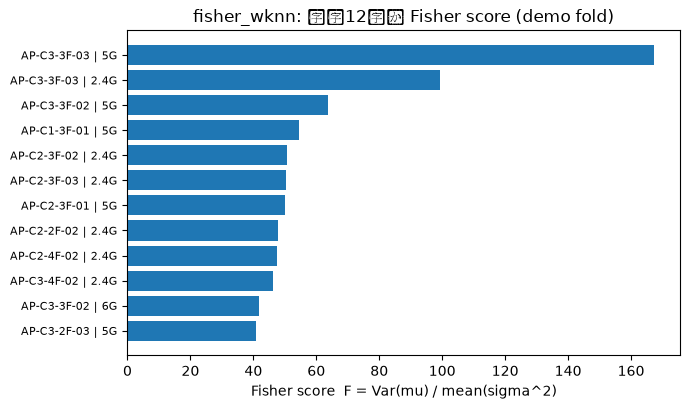

In [4]:
from icsr8.methods.fisher_wknn import FisherWknn, _fisher_scores

scores = _fisher_scores(demo_stats)
top = sorted(scores.items(), key=lambda kv: -kv[1])[:12]

fm = FisherWknn().fit(demo_train, ap13, truth)
print("diagnostics_:", fm.diagnostics_)
print(f"評価対象鍵 {len(scores)} 本のうち上位 {fm.diagnostics_['selected_M']} 本を採用")

labels = [f"{a} | {b}" for (a, b), _ in top]
vals = [v for _, v in top]
fig, ax = plt.subplots(figsize=(7, 4.2))
ypos = np.arange(len(vals))
ax.barh(ypos, vals, color="tab:blue")
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Fisher score  F = Var(mu) / mean(sigma^2)")
ax.set_title("fisher_wknn: 上位12鍵の Fisher score (demo fold)")
plt.tight_layout()
plt.show()


### 3.2 mahalanobis_wknn — 共分散 shrinkage による距離計量

L2 距離を Mahalanobis 距離 $d^2=(r-\mu)^\top \hat{\Sigma}^{-1}(r-\mu)$ に置換する。
地点数（59）は特徴次元より小さく標本共分散は必ず特異になるため、**Ledoit–Wolf
shrinkage** で正則化する。shrinkage 係数 $\lambda$ は「標本共分散（$\lambda=0$）と
対角スケール恒等（$\lambda=1$）をどれだけ混ぜるか」を表す。`cov_mode`（total /
within）・$k$・重み付けは inner CV で選ぶ。

diagnostics_: {'selected_cov_mode': 'within', 'selected_k': 3, 'selected_weighting': 'inv_sq'}

地点別 mu 行列 shape = (59, 102)  (地点数 < 特徴次元 → 標本共分散は特異)
Ledoit-Wolf shrinkage 係数 lambda = 0.0473
選択された cov_mode = within, k = 3


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2147538315.py:24: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2147538315.py:24: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2147538315.py:24: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2147538315.py:24: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2147538315.py:24: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6

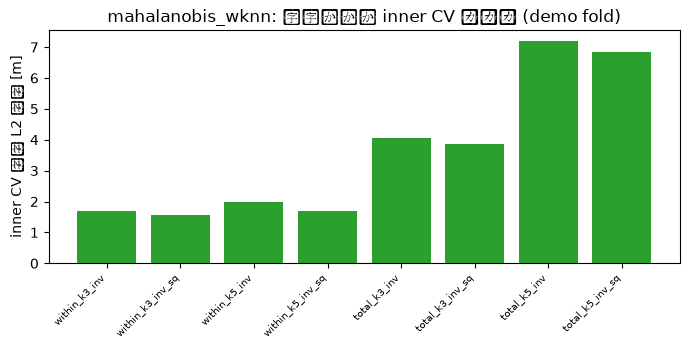

In [5]:
from sklearn.covariance import ledoit_wolf_shrinkage

from icsr8.methods.mahalanobis_wknn import MahalanobisWknn

mm = MahalanobisWknn().fit(demo_train, ap13, truth)
print("diagnostics_:", {k: v for k, v in mm.diagnostics_.items() if k != "cv_scores"})

# demo: 地点別 mu 行列に対する Ledoit-Wolf shrinkage 係数を直接計算して感触を掴む
mat, _keys = dense_matrix(demo_stats.mu)
lam = ledoit_wolf_shrinkage(mat)
print(f"\n地点別 mu 行列 shape = {mat.shape}  (地点数 < 特徴次元 → 標本共分散は特異)")
print(f"Ledoit-Wolf shrinkage 係数 lambda = {lam:.4f}")
print(f"選択された cov_mode = {mm.diagnostics_['selected_cov_mode']}, "
      f"k = {mm.diagnostics_['selected_k']}")

cv = mm.diagnostics_["cv_scores"]
fig, ax = plt.subplots(figsize=(7, 3.6))
names = list(cv.keys())
ax.bar(range(len(names)), [cv[n] for n in names], color="tab:green")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("inner CV 平均 L2 誤差 [m]")
ax.set_title("mahalanobis_wknn: 候補ごとの inner CV スコア (demo fold)")
plt.tight_layout()
plt.show()


### 3.3 pls_corridor — PLS 成分数の CV 曲線

廊下が 1 次元多様体であることを利用し、100 次元超の $\mu$ 特徴を少数の PLS 潜在成分に
圧縮してから廊下弧長 $s$ を直接回帰する。成分数 $n\_components$ は inner CV で選ぶ。
下の CV 曲線が「成分を増やすと過学習に転じる」典型的な U 字を描く。

diagnostics_: {'component_grid': [2, 3, 4, 6, 8, 10], 'selected_n_components_candidate': 6, 'selected_n_components_actual': 6, 'n_features_after_drop': 102, 'n_train_locations': 59}


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2440589423.py:19: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2440589423.py:19: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2440589423.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2440589423.py:19: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2440589423.py:19: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6

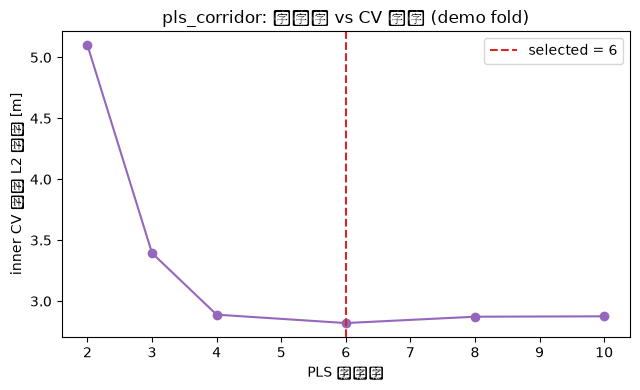

In [6]:
from icsr8.methods.pls_corridor import PlsCorridor

pm = PlsCorridor().fit(demo_train, ap13, truth)
diag = pm.diagnostics_
print("diagnostics_:", {k: v for k, v in diag.items() if k != "cv_scores"})

cv = diag["cv_scores"]  # {n_components: inner CV L2 誤差}
grid = list(cv.keys())
vals = [cv[g] for g in grid]
best = diag["selected_n_components_actual"]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(grid, vals, "o-", color="tab:purple")
ax.axvline(best, color="tab:red", ls="--", label=f"selected = {best}")
ax.set_xlabel("PLS 成分数")
ax.set_ylabel("inner CV 平均 L2 誤差 [m]")
ax.set_title("pls_corridor: 成分数 vs CV 誤差 (demo fold)")
ax.legend()
plt.tight_layout()
plt.show()


### 3.4 ordinal_corridor — p_k の単調化（isotonic 射影）前後

各閾値 $c_k$ で独立に二値ロジット $P(s>c_k)$ を学習するため、生の予測列
$p_1,\dots,p_m$ は必ずしも単調非増加にならない（生存確率なのに途中で増える等の
矛盾が出る）。予測時に **isotonic 回帰で非増加へ射影**してから階段積分で期待弧長を
再構成する。この単調化ステップ（実装関数 `_isotonic_nonincreasing`）の効果を示す。

diagnostics_: {'selected_m': 12, 'selected_C': 1.0, 'n_degenerate_thresholds': 0}


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/3798341093.py:22: UserWarning: Glyph 38334 (\N{CJK UNIFIED IDEOGRAPH-95BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/3798341093.py:22: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/3798341093.py:22: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/3798341093.py:22: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/3798341093.py:22: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6

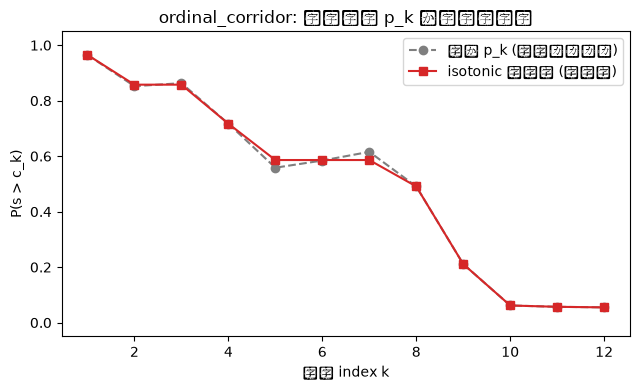

In [7]:
from icsr8.methods.ordinal_corridor import OrdinalCorridor, _isotonic_nonincreasing

om = OrdinalCorridor().fit(demo_train, ap13, truth)
print("diagnostics_:", {k: v for k, v in om.diagnostics_.items() if k != "cv_scores"})

# 独立フィットが生みうる非単調な生存確率列の例に isotonic 射影を適用
rng = np.random.default_rng(RANDOM_SEED)
p_raw = np.clip(
    np.linspace(0.95, 0.05, 12) + rng.normal(0, 0.12, 12), 0.0, 1.0
)
p_mono = _isotonic_nonincreasing(p_raw)

fig, ax = plt.subplots(figsize=(6.5, 4))
xs = np.arange(1, len(p_raw) + 1)
ax.plot(xs, p_raw, "o--", color="tab:gray", label="生の p_k (独立フィット)")
ax.plot(xs, p_mono, "s-", color="tab:red", label="isotonic 射影後 (非増加)")
ax.set_xlabel("閾値 index k")
ax.set_ylabel("P(s > c_k)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("ordinal_corridor: 生存確率 p_k の単調化前後")
ax.legend()
plt.tight_layout()
plt.show()


### 3.5 wcl_residual — WCL 弧長推定への補正量

baseline WCL の弧長推定 $s_{\text{wcl}}$ を、$[\mu\text{行列}, s_{\text{wcl}}]$ を
特徴とする Ridge 回帰の残差 $g(\cdot)$ で補正する: $\hat{s}=\mathrm{clip}(s_{\text{wcl}}+g)$。
下では test fold で「WCL のみ」と「WCL + 残差補正」の推定弧長を比べ、補正量
$\hat{s}-s_{\text{wcl}}$ の分布を見る。

diagnostics_: {'selected_alpha': 1.0, 'alpha_grid': [0.1, 1.0, 10.0, 100.0], 'n_train_locations': 59}
補正量 |s_hat - s_wcl| : 中央 2.18 m, 最大 10.38 m  (alpha=1.0)


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2977135624.py:30: UserWarning: Glyph 35036 (\N{CJK UNIFIED IDEOGRAPH-88DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2977135624.py:30: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2977135624.py:30: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2977135624.py:30: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/2977135624.py:30: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6

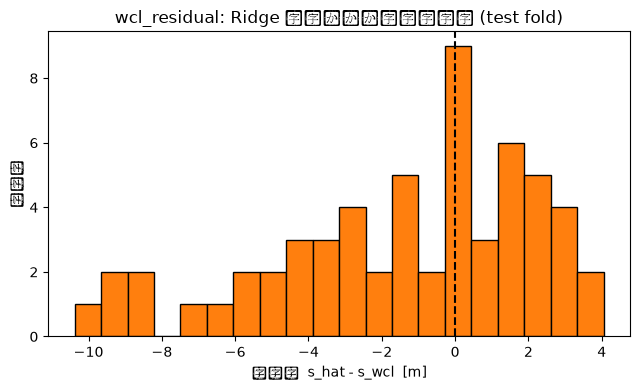

In [8]:
from icsr8.methods import run_method
from icsr8.methods.wcl_residual import WclResidual

wr = WclResidual().fit(demo_train, ap13, truth)
print("diagnostics_:", {k: v for k, v in wr.diagnostics_.items() if k != "cv_scores"})

# WCL 単独推定 (公開 run_method) の弧長
est_wcl = run_method("wcl", demo_train, demo_test, ap13, truth)
s_wcl = est_wcl.assign(
    s=lambda d: [xy_to_arclength(x, y) for x, y in zip(d["x"], d["y"])]
).set_index("location_p")["s"]

# WCL + 残差補正推定の弧長
est_res = wr.predict(demo_test)
s_res = est_res.assign(
    s=lambda d: [xy_to_arclength(x, y) for x, y in zip(d["x"], d["y"])]
).set_index("location_p")["s"]

common = s_wcl.index.intersection(s_res.index)
correction = (s_res.loc[common] - s_wcl.loc[common]).to_numpy()
print(f"補正量 |s_hat - s_wcl| : 中央 {np.median(np.abs(correction)):.2f} m, "
      f"最大 {np.max(np.abs(correction)):.2f} m  (alpha={wr.diagnostics_['selected_alpha']})")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(correction, bins=20, color="tab:orange", edgecolor="k")
ax.axvline(0, color="k", ls="--")
ax.set_xlabel("補正量  s_hat - s_wcl  [m]")
ax.set_ylabel("地点数")
ax.set_title("wcl_residual: Ridge 残差による弧長補正量 (test fold)")
plt.tight_layout()
plt.show()


### 3.6 joint_fp — RSSI 距離 + 検出率距離の複合

距離を $d(q,l)=\underbrace{\sum_k (r_k-\mu_{l,k})^2/(\sigma_{l,k}^2+\varepsilon)}_{\text{RSSI 項}}
+ \eta\cdot\underbrace{\sum_k (\hat{d}_k-\hat{q}_{l,k})^2}_{\text{検出率項}}$
とし、混合係数 $\eta$・$k$・重み付けを inner CV で選ぶ。$\eta=0$ は純 RSSI 距離、
$\eta$ を上げるほど「どの AP が見えた/見えないか」の検出パターンを重視する。

diagnostics_: {'selected_eta': 4.0, 'selected_k': 5, 'selected_weighting': 'inv_sq'}


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1401237979.py:23: UserWarning: Glyph 26908 (\N{CJK UNIFIED IDEOGRAPH-691C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1401237979.py:23: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1401237979.py:23: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1401237979.py:23: UserWarning: Glyph 38917 (\N{CJK UNIFIED IDEOGRAPH-9805}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1401237979.py:23: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yng

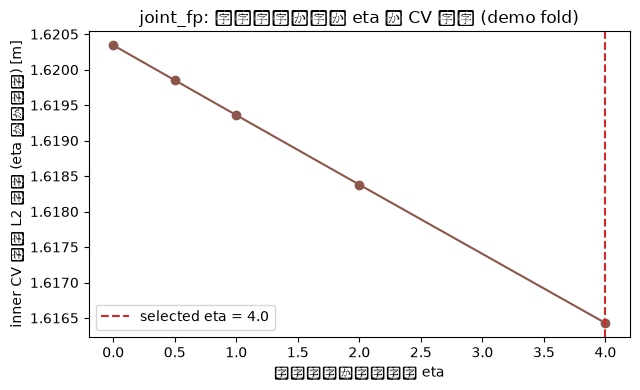

In [9]:
from icsr8.methods.joint_fp import JointFp

jm = JointFp().fit(demo_train, ap13, truth)
print("diagnostics_:", {k: v for k, v in jm.diagnostics_.items() if k != "cv_scores"})

# cv_scores を eta ごとの最良値に集約して「検出率項の効き」を見る
cv = jm.diagnostics_["cv_scores"]  # {'eta=..,k=..,w=..': score}
by_eta: dict[float, float] = {}
for key, val in cv.items():
    eta = float(key.split(",")[0].split("=")[1])
    by_eta[eta] = min(by_eta.get(eta, np.inf), val)
etas = sorted(by_eta)
vals = [by_eta[e] for e in etas]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(etas, vals, "o-", color="tab:brown")
ax.axvline(jm.diagnostics_["selected_eta"], color="tab:red", ls="--",
           label=f"selected eta = {jm.diagnostics_['selected_eta']}")
ax.set_xlabel("検出率項の混合係数 eta")
ax.set_ylabel("inner CV 平均 L2 誤差 (eta ごと最良) [m]")
ax.set_title("joint_fp: 検出率項の重み eta と CV 誤差 (demo fold)")
ax.legend()
plt.tight_layout()
plt.show()


### 3.7 gp_augmented_wknn — 廊下上の仮想 fingerprint 点列

各鍵の RSSI を廊下弧長 $s$ の 1D Gaussian Process でモデル化し、間隔 $\Delta$ の
グリッド上に**仮想参照点**を合成する（半教師 data augmentation）。query は実測点と
仮想点の合同集合に L2 近傍投票し、仮想点の重みは $w_{\text{virt}}$ で減衰する。
下では合成された仮想 fingerprint 点列を L 字廊下上に可視化する。

diagnostics_: {'selected_delta': 2.0, 'selected_w_virt': 1.0, 'selected_k': 5, 'n_gp_keys': 89, 'n_real_refs': 59, 'n_virtual_refs': 59}


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/848409299.py:23: UserWarning: Glyph 24266 (\N{CJK UNIFIED IDEOGRAPH-5ECA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/848409299.py:23: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/848409299.py:23: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/848409299.py:23: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/848409299.py:23: UserWarning: Glyph 20206 (\N{CJK UNIFIED IDEOGRAPH-4EEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3

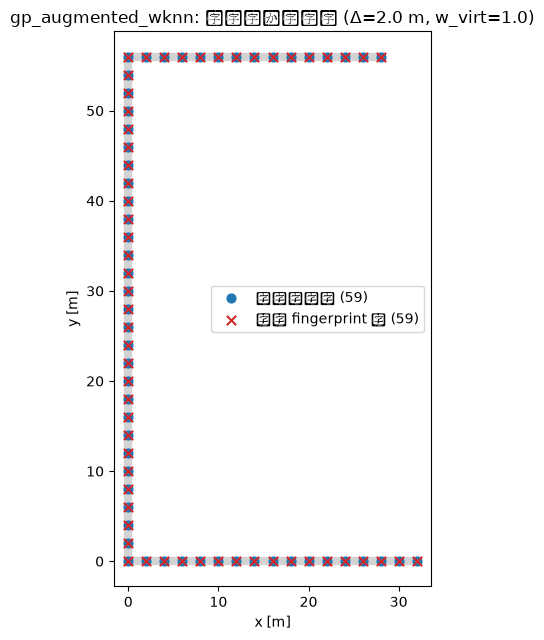

In [10]:
from icsr8.methods.gp_augmented_wknn import GpAugmentedWknn

gm = GpAugmentedWknn().fit(demo_train, ap13, truth)
print("diagnostics_:", {k: v for k, v in gm.diagnostics_.items() if k != "cv_scores"})

virt_xy = gm._virtual_xy       # (n_virt, 2) 仮想点座標
real_xy = gm._model.real_xy    # (n_real, 2) 実測参照点座標

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for (ax0, ay0), (ax1, ay1) in CORRIDOR_SEGMENTS:
    ax.plot([ax0, ax1], [ay0, ay1], color="lightgray", lw=6, zorder=0)
ax.scatter(real_xy[:, 0], real_xy[:, 1], c="tab:blue", s=40,
           label=f"実測参照点 ({len(real_xy)})", zorder=2)
ax.scatter(virt_xy[:, 0], virt_xy[:, 1], c="tab:red", marker="x", s=45,
           label=f"仮想 fingerprint 点 ({len(virt_xy)})", zorder=3)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"gp_augmented_wknn: 廊下上の仮想点 "
             f"(Δ={gm.diagnostics_['selected_delta']} m, "
             f"w_virt={gm.diagnostics_['selected_w_virt']})")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Protocol A（2 fold・9 手法）フル計算

`run_protocol_a_tier4` で Protocol A の 2 fold（forward↔backward）を
9 手法（Tier4 の 7 + 参照 `wcl`, `gp_corridor`）について評価する。各行が
1 手法・1 fold の指標で、`delta_vs_wcl` / `delta_vs_gp_corridor` は paired
bootstrap（B=1000, seed=0）の点推定である。

In [11]:
t0 = time.perf_counter()
pa_results, _pa_ledger, pa_diag = run_protocol_a_tier4(
    TIER4_METHODS, REFERENCE_METHODS,
    scans_f, scans_b, ap13, truth, seed=SEED, B=B,
)
timings["protocol_a"] = time.perf_counter() - t0
print(f"Protocol A 完了: {timings['protocol_a']:.1f} s  行数={len(pa_results)}")

show_cols = ["method", "fold", "ave", "median", "p90", "within_2m",
             "delta_vs_wcl", "delta_vs_gp_corridor", "status"]
pa_results[show_cols].round(3)


Protocol A 完了: 24.3 s  行数=18


,method,fold,ave,median,p90,within_2m,delta_vs_wcl,delta_vs_gp_corridor,status
0,fisher_wknn,forward_to_backward,1.750,1.248,3.831,0.763,-1.762,0.851,ok
1,mahalanobis_wknn,forward_to_backward,1.064,0.495,2.634,0.814,-2.449,0.164,ok
2,pls_corridor,forward_to_backward,3.486,3.037,6.982,0.339,-0.027,2.586,ok
3,ordinal_corridor,forward_to_backward,4.160,4.020,6.704,0.186,0.647,3.260,ok
4,wcl_residual,forward_to_backward,2.873,2.088,5.756,0.475,-0.639,1.974,ok
5,joint_fp,forward_to_backward,1.578,1.129,3.155,0.763,-1.935,0.678,ok
6,gp_augmented_wknn,forward_to_backward,1.436,1.327,3.024,0.746,-2.077,0.536,ok
7,wcl,forward_to_backward,3.512,2.815,6.091,0.305,0.000,2.613,ok
8,gp_corridor,forward_to_backward,0.899,0.661,2.322,0.881,-2.613,0.000,ok
9,fisher_wknn,backward_to_forward,1.370,1.441,2.596,0.763,-2.199,0.252,ok


## 5. LOLO（59 fold・9 手法）フル計算 + CDF

`run_lolo_tier4` で Leave-One-Location-Out（59 地点、各地点を 1 度ずつ hold-out）を
9 手法について評価する。空間汎化を測る最も厳しい設定で、`gp_corridor` /
`gp_augmented_wknn` の 2 つは GP フィットを毎 fold 行うため重い（進捗は stderr に出る）。
集約 `lolo_summary` の後に 9 手法の誤差 CDF をインライン描画する。

In [12]:
t0 = time.perf_counter()
lolo_ledger, lolo_summary, lolo_diag = run_lolo_tier4(
    TIER4_METHODS, REFERENCE_METHODS,
    scans_f, scans_b, ap13, truth, seed=SEED, B=B,
)
timings["lolo"] = time.perf_counter() - t0
print(f"\nLOLO 完了: {timings['lolo']:.1f} s  台帳行数={len(lolo_ledger)}")

lolo_show = lolo_summary.sort_values("ave").reset_index(drop=True)
lolo_cols = ["method", "ave", "median", "p90", "within_2m",
             "delta_vs_wcl", "delta_vs_gp_corridor", "status"]
lolo_show[lolo_cols].round(3)


[tier4] lolo fisher_wknn fold 1/59 (held_out=1)


[tier4] lolo fisher_wknn fold 2/59 (held_out=2)


[tier4] lolo fisher_wknn fold 3/59 (held_out=3)


[tier4] lolo fisher_wknn fold 4/59 (held_out=4)


[tier4] lolo fisher_wknn fold 5/59 (held_out=5)


...

[tier4] lolo gp_corridor fold 52/59 (held_out=52)
[tier4] lolo gp_corridor fold 53/59 (held_out=53)
[tier4] lolo gp_corridor fold 54/59 (held_out=54)


[tier4] lolo gp_corridor fold 55/59 (held_out=55)
[tier4] lolo gp_corridor fold 56/59 (held_out=56)
[tier4] lolo gp_corridor fold 57/59 (held_out=57)


[tier4] lolo gp_corridor fold 58/59 (held_out=58)
[tier4] lolo gp_corridor fold 59/59 (held_out=59)



LOLO 完了: 689.8 s  台帳行数=531


,method,ave,median,p90,within_2m,delta_vs_wcl,delta_vs_gp_corridor,status
0,gp_corridor,0.725,0.502,1.739,0.898,-2.788,0.000,ok
1,mahalanobis_wknn,1.765,1.293,3.824,0.763,-1.747,1.040,ok
2,gp_augmented_wknn,1.875,1.700,3.662,0.576,-1.638,1.150,ok
3,joint_fp,2.091,1.396,4.192,0.610,-1.421,1.366,ok
4,fisher_wknn,2.122,1.496,4.252,0.661,-1.390,1.397,ok
5,wcl_residual,3.240,2.462,6.229,0.407,-0.273,2.515,ok
6,wcl,3.512,2.815,6.091,0.305,0.000,2.788,ok
7,pls_corridor,3.794,3.213,8.351,0.390,0.281,3.069,ok
8,ordinal_corridor,4.603,4.460,7.449,0.169,1.090,3.878,ok


/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1175870398.py:23: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1175870398.py:23: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1175870398.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1175870398.py:23: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6mn915yngx55y3qqcybf00000gn/T/ipykernel_17245/1175870398.py:23: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4p/c6d6

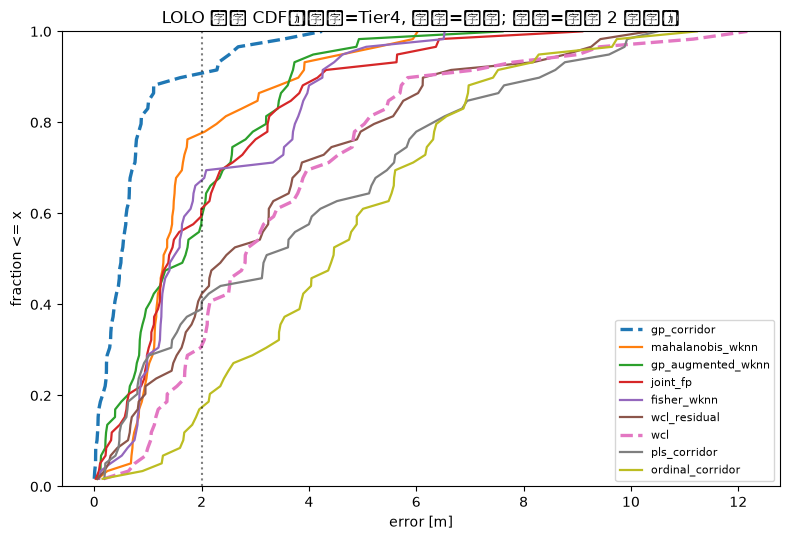

In [13]:
# LOLO 誤差 CDF（9 手法、平均誤差昇順で凡例）
order = (
    lolo_ledger.groupby("method")["error"].mean().sort_values().index.tolist()
)
fig, ax = plt.subplots(figsize=(8, 5.5))
for method in order:
    errs = np.sort(
        lolo_ledger.loc[lolo_ledger["method"] == method, "error"]
        .dropna().to_numpy(dtype=float)
    )
    if len(errs) == 0:
        continue
    y = np.arange(1, len(errs) + 1) / len(errs)
    ls = "-" if method in TIER4_METHODS else "--"
    lw = 2.4 if method in REFERENCE_METHODS else 1.6
    ax.plot(errs, y, ls, lw=lw, label=method)
ax.axvline(2.0, color="k", ls=":", alpha=0.5)
ax.set_xlabel("error [m]")
ax.set_ylabel("fraction <= x")
ax.set_ylim(0, 1)
ax.set_title("LOLO 誤差 CDF（実線=Tier4, 破線=参照; 太線=参照 2 手法）")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. 診断値（inner CV で選択されたハイパーパラメータ）

各手法が Protocol A の各 fold で inner CV により選んだハイパーパラメータを一覧する
（`mahalanobis` の `cov_mode`/`k`、`joint_fp` の $\eta$、`gp_augmented` の
$\Delta$/$w_{\text{virt}}$/$k$ など）。`diagnostics_` を長形式で集約した `pa_diag` /
`lolo_diag` から、CV スコア辞書のような大きな値を除いたスカラー選択値を表示する。

In [14]:
scalar_keys = {
    "selected_M", "selected_k", "selected_weighting",       # fisher
    "selected_cov_mode",                                    # mahalanobis
    "selected_n_components_actual", "n_features_after_drop",  # pls
    "selected_m", "selected_C",                             # ordinal
    "selected_alpha",                                       # wcl_residual
    "selected_eta",                                         # joint_fp
    "selected_delta", "selected_w_virt",                   # gp_augmented
    "n_virtual_refs", "n_gp_keys",
}
pa_sel = pa_diag[pa_diag["key"].isin(scalar_keys)].copy()
pivot = (
    pa_sel.pivot_table(
        index=["method", "fold"], columns="key", values="value", aggfunc="first"
    )
)
pivot


key                                   n_features_after_drop n_gp_keys  \
method            fold                                                  
fisher_wknn       backward_to_forward                   NaN       NaN   
                  forward_to_backward                   NaN       NaN   
gp_augmented_wknn backward_to_forward                   NaN        93   
                  forward_to_backward                   NaN        89   
joint_fp          backward_to_forward                   NaN       NaN   
                  forward_to_backward                   NaN       NaN   
mahalanobis_wknn  backward_to_forward                   NaN       NaN   
                  forward_to_backward                   NaN       NaN   
ordinal_corridor  backward_to_forward                   NaN       NaN   
                  forward_to_backward                   NaN       NaN   
pls_corridor      backward_to_forward                   101       NaN   
                  forward_to_backward                   102       NaN   
wcl_residual      backward_to_forward                   NaN       NaN   
                  forward_to_backward                   NaN       NaN   

key                                   n_virtual_refs selected_C selected_M  \
method            fold                                                       
fisher_wknn       backward_to_forward            NaN        NaN        all   
                  forward_to_backward            NaN        NaN         32   
gp_augmented_wknn backward_to_forward             30        NaN        NaN   
                  forward_to_backward             59        NaN        NaN   
joint_fp          backward_to_forward            NaN        NaN        NaN   
                  forward_to_backward            NaN        NaN        NaN   
mahalanobis_wknn  backward_to_forward            NaN        NaN        NaN   
                  forward_to_backward            NaN        NaN        NaN   
ordinal_corridor  backward_to_forward            NaN        1.0        NaN   
                  forward_to_backward            NaN        1.0        NaN   
pls_corridor      backward_to_forward            NaN        NaN        NaN   
                  forward_to_backward            NaN        NaN        NaN   
wcl_residual      backward_to_forward            NaN        NaN        NaN   
                  forward_to_backward            NaN        NaN        NaN   

key                                   selected_alpha selected_cov_mode  \
method            fold                                                   
fisher_wknn       backward_to_forward            NaN               NaN   
                  forward_to_backward            NaN               NaN   
gp_augmented_wknn backward_to_forward            NaN               NaN   
                  forward_to_backward            NaN               NaN   
joint_fp          backward_to_forward            NaN               NaN   
                  forward_to_backward            NaN               NaN   
mahalanobis_wknn  backward_to_forward            NaN            within   
                  forward_to_backward            NaN            within   
ordinal_corridor  backward_to_forward            NaN               NaN   
                  forward_to_backward            NaN               NaN   
pls_corridor      backward_to_forward            NaN               NaN   
                  forward_to_backward            NaN               NaN   
wcl_residual      backward_to_forward            0.1               NaN   
                  forward_to_backward            1.0               NaN   

key                                   selected_delta selected_eta selected_k  \
method            fold                                                         
fisher_wknn       backward_to_forward            NaN          NaN          3   
                  forward_to_backward            NaN          NaN          5   
gp_augmented_wknn backward_to_forward            4.0          NaN          5 

## 7. 照合セル（必須）— 凍結 `results/tier4/` との一致確認

本ノートがメモリ上で計算した `pa_results` / `lolo_summary` を、本番
`results/tier4/protocol_a.csv` / `lolo_summary.csv`（`delta_vs_wcl` /
`delta_vs_gp_corridor` 列を含む）と `assert_allclose(atol=1e-6)` で照合する。
文字列列（`status`）も要素一致を確認し、行は `(method, fold)`（summary は
`method`）で厳密整列してから比較する。

In [15]:
def _assert_match(computed, frozen_path, index_cols, label):
    frozen = pd.read_csv(frozen_path)
    a = computed.set_index(index_cols).sort_index()
    b = frozen.set_index(index_cols).sort_index()
    assert list(a.index) == list(b.index), f"{label}: 行 index 不一致"
    num_cols = [c for c in b.columns if pd.api.types.is_numeric_dtype(b[c])]
    a = a.reindex(b.index)
    for c in num_cols:
        np.testing.assert_allclose(
            a[c].to_numpy(dtype=float), b[c].to_numpy(dtype=float),
            atol=1e-6, equal_nan=True, err_msg=f"{label}: 列 {c} 不一致",
        )
    if "status" in b.columns:
        assert (a["status"].to_numpy() == b["status"].to_numpy()).all(), \
            f"{label}: status 不一致"
    assert (b["status"] == "ok").all(), f"{label}: status に ok 以外"
    print(f"  {label}: {len(b)} 行 x {len(num_cols)} 数値列 一致 (atol=1e-6)")


print("凍結 results/tier4 との照合:")
_assert_match(pa_results, RESULTS_DIR / "protocol_a.csv",
              ["method", "fold"], "protocol_a")
_assert_match(lolo_summary, RESULTS_DIR / "lolo_summary.csv",
              ["method"], "lolo_summary")
print("\n照合結果: 一致")


凍結 results/tier4 との照合:
  protocol_a: 18 行 x 14 数値列 一致 (atol=1e-6)
  lolo_summary: 9 行 x 10 数値列 一致 (atol=1e-6)

照合結果: 一致


## 8. 実行環境と所要時間

In [16]:
print("実行環境:")
print(f"  Python : {platform.python_version()}")
print(f"  NumPy  : {np.__version__}")
print(f"  pandas : {pd.__version__}")
print(f"  platform: {platform.platform()}")
print(f"\n乱数種 seed={SEED}, bootstrap B={B}")
print("\nセクション別所要時間:")
for name, sec in timings.items():
    print(f"  {name:12s}: {sec:8.1f} s")
print(f"  {'合計':12s}: {sum(timings.values()):8.1f} s")

best = lolo_summary[lolo_summary["method"].isin(TIER4_METHODS)].sort_values("ave").iloc[0]
print(f"\nTier4 最良手法 (LOLO Ave): {best['method']} = {best['ave']:.3f} m")
print(f"参照 gp_corridor (LOLO Ave): "
      f"{lolo_summary.set_index('method').loc['gp_corridor', 'ave']:.3f} m")


実行環境:
  Python : 3.11.14
  NumPy  : 2.4.6
  pandas : 3.0.4
  platform: macOS-27.0-arm64-arm-64bit

乱数種 seed=0, bootstrap B=1000

セクション別所要時間:
  data_load   :      0.0 s
  protocol_a  :     24.3 s
  lolo        :    689.8 s
  合計          :    714.1 s

Tier4 最良手法 (LOLO Ave): mahalanobis_wknn = 1.765 m
参照 gp_corridor (LOLO Ave): 0.725 m
